In [2]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os
import IPython.display as ipd
from scipy.io.wavfile import write

**El proceso va a ser recorrer todos los archivos**
* 1. Padd si es necesario
* 2. sacar la STFT 
* 3. pasar a dB
* 4. normalizar y guardar 

In [38]:
#cada audio deberia de tener 512 muestras
def load_dataset(path):
    array, sr = librosa.load(path, sr= 44100)
    #print(array.shape)
    return array, sr

def padder(array, num_expected_samples = 512):
    if len(array) < num_expected_samples:
        missing_samples = num_expected_samples - len(array)
        padded_array = np.pad(array, (0, missing_samples), mode='constant')
        #print(padded_array.shape)
        print('ACA')
        return padded_array
    elif len(array) == num_expected_samples:
        return array
    else:
        print("ERROR ACA")
        return array
    
def extraer_log_espectrograma(array):
    n_fft = 512 # La cantidad de puntos muestreados en cada FFT
    hop_length = 128 # Cuanto nos movemos en cada FFT 
    stft = librosa.stft(array, n_fft= n_fft,  hop_length= hop_length)[:-1]
    espectrograma = np.abs(stft)
    log_spectrograma = librosa.amplitude_to_db(espectrograma)
    #print(log_spectrograma.shape)
    return log_spectrograma

def normalizar(array):
    norm_array = (array - array.min())/ (array.max() - array.min())
    return norm_array

In [39]:
lista_espectrogramas_normalizados = []
lista_etiquetas = [] # Left-right/ elev / az -> (0/1, elev: int, az: int)
i= 0 
for root, _, files in os.walk("MIT KEMAR Dataset"):
    if i == 0:
        i+=1
        continue
    for file in files:
        path = os.path.join(root, file)
        array, sr = load_dataset(path)
        array = padder(array)
        espectrograma = extraer_log_espectrograma(array)
        espectrograma_norm = normalizar(espectrograma)
        lista_espectrogramas_normalizados.append(espectrograma_norm)

espectrogramas = np.array(lista_espectrogramas_normalizados)
print(espectrogramas.shape)
    
    

(1420, 256, 5)


Tenemos 1420 datos para procesar, voy a dejar un 10% de testeo que son 142 datos 

In [48]:
import random

indices_test = random.sample(range(1420), 142)

train_indices = list(set(range(1420)) - set(indices_test))

train_data = espectrogramas[train_indices]
test_data = espectrogramas[indices_test]

print(train_data.shape)
print(test_data.shape)

(1278, 256, 5)
(142, 256, 5)


Ahi tenemos el train y el test con los datos correspondientes, para asegurar que efectivamente hay un espectrograma lo voy a plotear sacando una muestra cualquiera de los datos de train

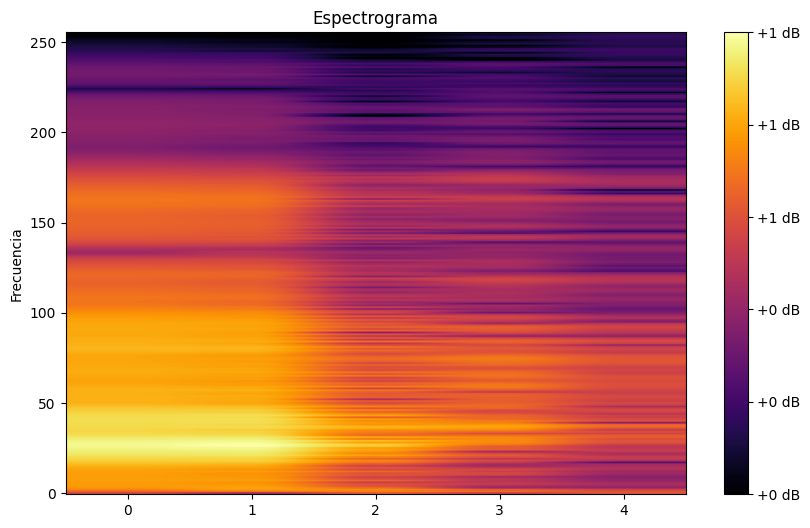

In [56]:
random_sample = random.choice(train_data)

plt.figure(figsize=(10, 6))
plt.imshow(random_sample, aspect='auto', origin='lower', cmap='inferno')
plt.colorbar(format='%+2.0f dB')
plt.title("Espectrograma")
plt.ylabel("Frecuencia")
plt.show()

Podría probar dejando los MFCC, pero no se, ahora voy a guardar train y test en un npz

In [57]:
np.savez("train_data_test_data.npz", train_data= train_data, test_data = test_data)